Residence time  = 200.0 s
Rate constant k(T) = 0.0484 1/s
Damkohler number Da = 9.68

Analytical steady state:
C_A_ss = 0.1873 mol/L
X_ss   = 0.9064  (90.64%)

ODE result at t_end:
C_A    = 0.1873 mol/L
X      = 0.9064  (90.64%)


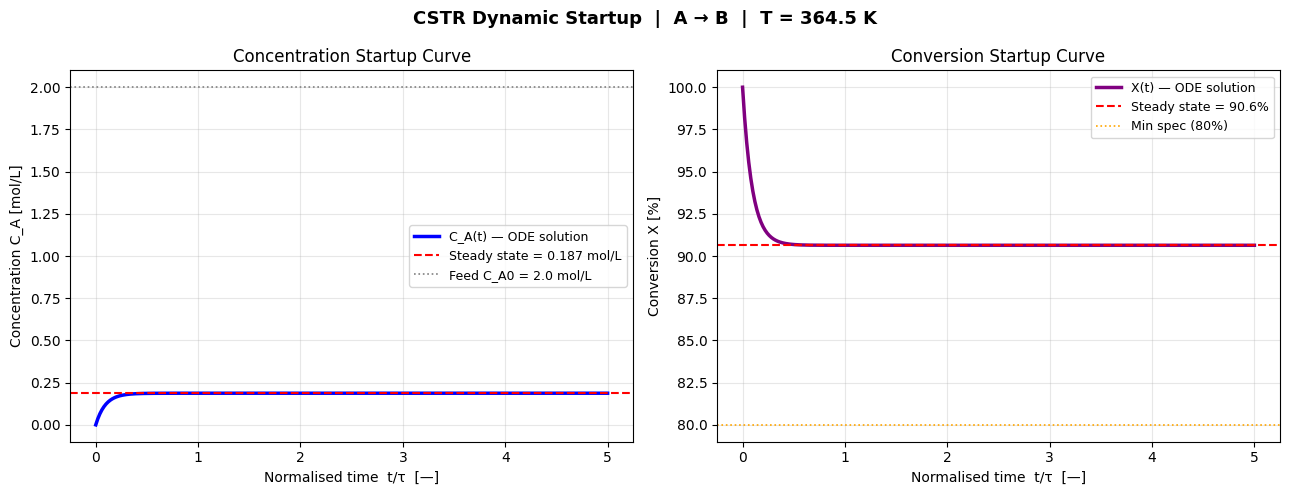

✓ Saved as cstr_startup.png


In [2]:
# Phase 1: Dynamic CSTR Startup

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Process parameters
k0  = 1e8     # pre-exponential factor  [1/s]
Ea  = 65000   # activation energy       [J/mol]
R   = 8.314   # gas constant            [J/mol.K]
T   = 364.5   # optimal temperature     [K]
C_A0 = 2.0    # feed concentration      [mol/L]
V   = 500.0   # reactor volume          [L]
v0  = 2.5     # volumetric flow rate    [L/s]
tau = V / v0  # residence time          [s]

# Reaction rate constant at optimal T
k = k0 * np.exp(-Ea / (R * T))
print(f"Residence time  = {tau:.1f} s")
print(f"Rate constant k(T) = {k:.4f} 1/s")
print(f"Damkohler number Da = {k*tau:.2f}")

# Define the ODE
def cstr_ode(t, C_A):
  """
  ODE for CSTR concentration of A over time.
  C_A : current concentration of A [mol/L]
  t   : time [s]
  Returns: dC_A/dt
  """
  dCA_dt = (C_A0 - C_A) / tau - k * C_A
  return [dCA_dt]

# Initial condition and time span
C_A_init   = [0.0]    # reactor starts empty (C_A = 0 at t = 0)
t_start    = 0
t_end      = 5 * tau   # simulate for 5 residence times
t_eval     = np.linspace(0, t_end, 500)     # 500 time points

# Solve the ODE
solution = solve_ivp(
      fun   = cstr_ode,
      t_span = (t_start, t_end),
      y0     = C_A_init,
      t_eval = t_eval,
      method = 'RK45',         # standard Runge-Kutta solver
      rtol   = 1e-8            # tight tolerance for accuracy

  )

# Extract results
t_out  = solution.t
CA_out = solution.y[0]
X_out  = 1 - CA_out / C_A0      # conversion at each time point


# Analytical steady state
Da     = k * tau
X_ss   = Da / (1 + Da)
CA_ss  = C_A0 * (1 - X_ss)

print(f"\nAnalytical steady state:")
print(f"C_A_ss = {CA_ss:.4f} mol/L")
print(f"X_ss   = {X_ss:.4f}  ({X_ss*100:.2f}%)")
print(f"\nODE result at t_end:")
print(f"C_A    = {CA_out[-1]:.4f} mol/L")
print(f"X      = {X_out[-1]:.4f}  ({X_out[-1]*100:.2f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("CSTR Dynamic Startup  |  A → B  |  T = 364.5 K",
             fontsize=13, fontweight='bold')

# Normalise time by τ for cleaner x-axis
t_norm = t_out / tau

ax1 = axes[0]
ax1.plot(t_norm, CA_out, 'b-', lw=2.5, label='C_A(t) — ODE solution')
ax1.axhline(CA_ss, color='red', ls='--', lw=1.5,
            label=f'Steady state = {CA_ss:.3f} mol/L')
ax1.axhline(C_A0, color='grey', ls=':', lw=1.2, label='Feed C_A0 = 2.0 mol/L')
ax1.set_xlabel('Normalised time  t/τ  [—]'); ax1.set_ylabel('Concentration C_A [mol/L]')
ax1.set_title('Concentration Startup Curve')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(t_norm, X_out * 100, 'purple', lw=2.5, label='X(t) — ODE solution')
ax2.axhline(X_ss * 100, color='red', ls='--', lw=1.5,
            label=f'Steady state = {X_ss*100:.1f}%')
ax2.axhline(80, color='orange', ls=':', lw=1.2, label='Min spec (80%)')
ax2.set_xlabel('Normalised time  t/τ  [—]'); ax2.set_ylabel('Conversion X [%]')
ax2.set_title('Conversion Startup Curve')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cstr_startup.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved as cstr_startup.png")


  STEP DISTURBANCE ANALYSIS
  Old steady state: C_A = 0.1873 mol/L
  New steady state: C_A = 0.2622 mol/L
  Change in C_A_ss: +0.0749 mol/L
  Conversion before and after: 90.64%
  (Conversion unchanged — why? Think about it!)


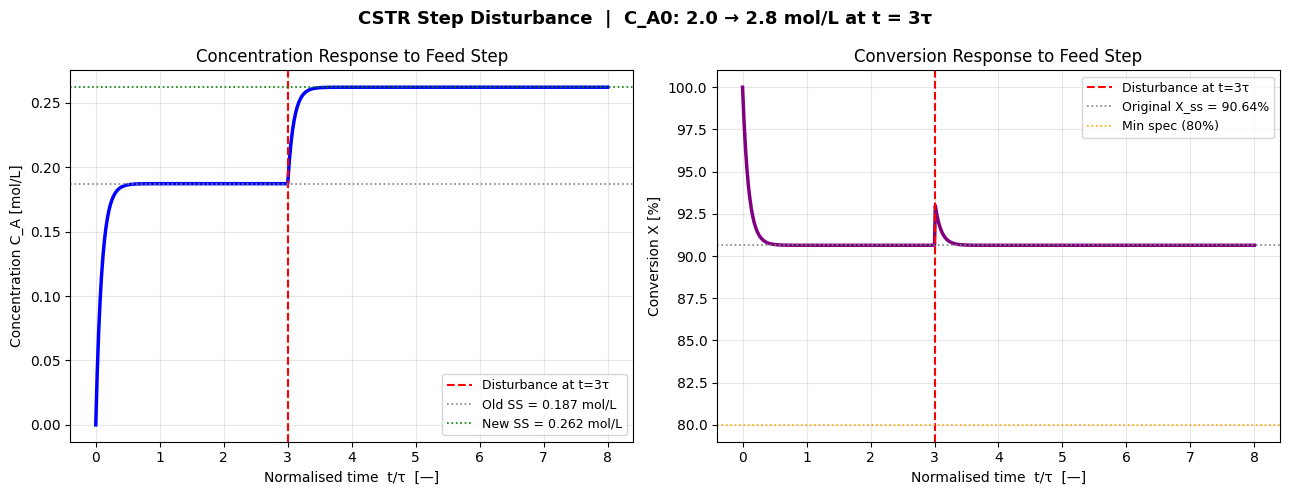

In [5]:
# Step Disturbance Response
# At τ = 3τ, feed concentration suddenly jumps C_A0: 2.0->2.8 mol/L

from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k0 = 1e8; Ea = 65000; R = 8.314; T = 364.5
C_A0_before = 2.0;   # mol/L -- original feed
C_A0_after = 2.8;    # mol/L -- new feed after disturbance (+40%)
V = 500.0; v0 = 2.5; τ = V/v0
k = k0 * np.exp(-Ea / (R * T))

t_switch = 3 * τ    # disturbance occurs at t = 3τ
t_total = 8 * τ    # simulate until t = 8τ

# ----- Segment 1: t = 0 -> 3τ  (Original feed) ---------
def ode_before(t, CA):
  return [(C_A0_before - CA[0]) / τ - k * CA[0]]

seg1 = solve_ivp(ode_before, (0, t_switch),
                 y0=[0.0],
                 t_eval=np.linspace(0, t_switch, 400),
                 method='RK45', rtol=1e-8)

CA_at_switch = seg1.y[0, -1]      # concentration when disturbance hits

# --- Segment 2: t = 3τ -> 8τ   (new higher feed) --------
def ode_after(t, CA):
  return [(C_A0_after - CA[0]) / τ - k * CA[0]]

seg2 = solve_ivp(ode_after, (t_switch, t_total),
                 y0=[CA_at_switch],
                 t_eval=np.linspace(t_switch, t_total, 400),
                 method='RK45', rtol=1e-8)

# --- Stitch segments together ----------
t_all = np.concatenate([seg1.t, seg2.t])
CA_all = np.concatenate([seg1.y[0], seg2.y[0]])
X_all = np.zeros(len(t_all))

for i in range(len(t_all)):
    if t_all[i] <= t_switch:
        X_all[i] = 1 - CA_all[i] / C_A0_before
    else:
        X_all[i] = 1 - CA_all[i] / C_A0_after

t_norm = t_all / tau

# Analytical new steady state
Da = k * tau
CA_ss_new = C_A0_after / (1 + Da)
X_ss_new  = 1 - CA_ss_new / C_A0_after   # same X! why?
CA_ss_old = C_A0_before / (1 + Da)

print("=" * 50)
print("  STEP DISTURBANCE ANALYSIS")
print("=" * 50)
print(f"  Old steady state: C_A = {CA_ss_old:.4f} mol/L")
print(f"  New steady state: C_A = {CA_ss_new:.4f} mol/L")
print(f"  Change in C_A_ss: +{CA_ss_new - CA_ss_old:.4f} mol/L")
print(f"  Conversion before and after: {X_ss_new*100:.2f}%")
print(f"  (Conversion unchanged — why? Think about it!)")
print("=" * 50)

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("CSTR Step Disturbance  |  C_A0: 2.0 → 2.8 mol/L at t = 3τ",
             fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.plot(t_norm, CA_all, 'b-', lw=2.5)
ax1.axvline(3, color='red', ls='--', lw=1.5, label='Disturbance at t=3τ')
ax1.axhline(CA_ss_old, color='grey', ls=':', lw=1.2,
            label=f'Old SS = {CA_ss_old:.3f} mol/L')
ax1.axhline(CA_ss_new, color='green', ls=':', lw=1.2,
            label=f'New SS = {CA_ss_new:.3f} mol/L')
ax1.set_xlabel('Normalised time  t/τ  [—]')
ax1.set_ylabel('Concentration C_A [mol/L]')
ax1.set_title('Concentration Response to Feed Step')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(t_norm, X_all * 100, 'purple', lw=2.5)
ax2.axvline(3, color='red', ls='--', lw=1.5, label='Disturbance at t=3τ')
ax2.axhline(90.64, color='grey', ls=':', lw=1.2, label='Original X_ss = 90.64%')
ax2.axhline(80, color='orange', ls=':', lw=1.2, label='Min spec (80%)')
ax2.set_xlabel('Normalised time  t/τ  [—]')
ax2.set_ylabel('Conversion X [%]')
ax2.set_title('Conversion Response to Feed Step')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cstr_disturbance.png', dpi=150, bbox_inches='tight')
plt.show()

  Experimental data summary:
     T [K]    C_A meas [mol/L]    k_apparent [1/s]
  ──────────────────────────────────────────────────
       330              0.9886             0.00511
       345              0.5148             0.01443
       355              0.3132             0.02693
       365              0.1900             0.04764
       375              0.1061             0.08927
       390              0.0484             0.20163

  PARAMETER ESTIMATION RESULTS
                Method        k0 [1/s]    Ea [J/mol]
  ────────────────────────────────────────────────────
           True values       1.000e+08       65000.0
      Linear Arrhenius       1.126e+08       65366.4
      Nonlinear (NLLS)       1.765e+08       66761.5
  ────────────────────────────────────────────────────
  NLLS uncertainty:  k0 ± 3.29e+07  |  Ea ± 598.4 J/mol

  Ea recovery error (NLLS): 2.71%


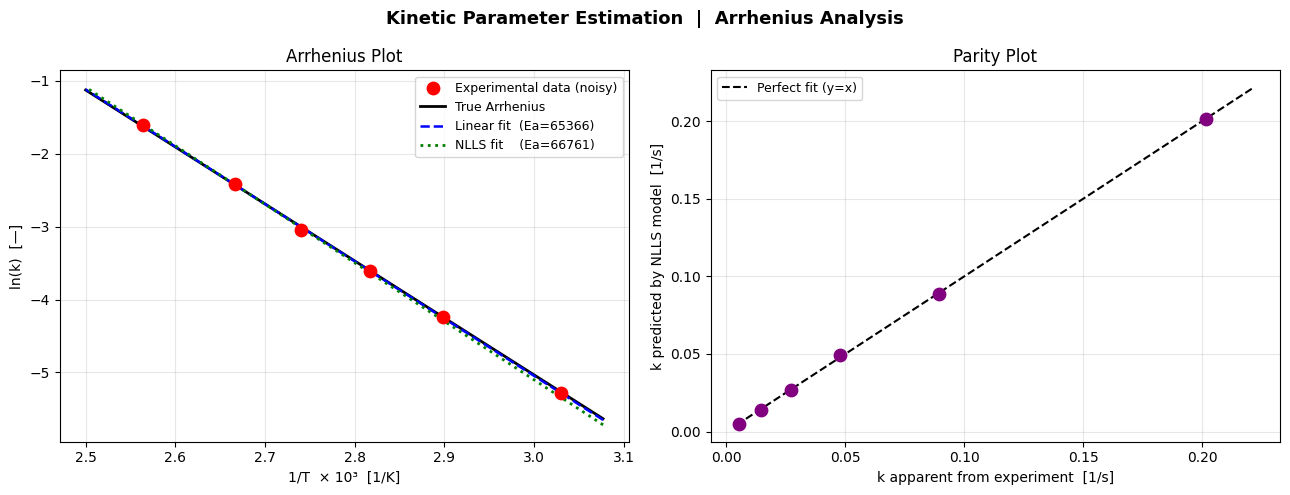

✓ Saved as parameter_estimation.png


In [6]:
# Cell 3 — Kinetic Parameter Estimation

from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)   # for reproducibility

# ── True parameters (what nature knows) ──────────────────────
k0_true = 1e8
Ea_true = 65000
R = 8.314; C_A0 = 2.0; V = 500.0; v0 = 2.5; tau = V / v0

# ── Generate synthetic experimental data ─────────────────────
# 6 experiments at different temperatures
T_experiments = np.array([330, 345, 355, 365, 375, 390], dtype=float)

CA_measured = []
for T in T_experiments:
    k_true    = k0_true * np.exp(-Ea_true / (R * T))
    CA_true   = C_A0 / (1 + k_true * tau)         # true steady-state C_A
    noise     = np.random.normal(0, 0.005)         # small measurement noise
    CA_measured.append(CA_true + noise)

CA_measured = np.array(CA_measured)

# Derive apparent k from each measurement
# From CSTR balance: C_A = C_A0 / (1 + k*τ)  → k = (C_A0/C_A - 1) / τ
k_apparent = (C_A0 / CA_measured - 1) / tau

print("  Experimental data summary:")
print(f"  {'T [K]':>8}  {'C_A meas [mol/L]':>18}  {'k_apparent [1/s]':>18}")
print(f"  {'─'*50}")
for i in range(len(T_experiments)):
    k_true_i = k0_true * np.exp(-Ea_true / (R * T_experiments[i]))
    print(f"  {T_experiments[i]:>8.0f}  {CA_measured[i]:>18.4f}  {k_apparent[i]:>18.5f}")

# ── Method 1: Linear Arrhenius fit ────────────────────────────
# ln(k) = ln(k0) - Ea/(R*T) → straight line in ln(k) vs 1/T
inv_T  = 1.0 / T_experiments
ln_k   = np.log(k_apparent)

# Fit a straight line: y = m*x + b → m = -Ea/R, b = ln(k0)
coeffs    = np.polyfit(inv_T, ln_k, deg=1)
Ea_linear = -coeffs[0] * R
k0_linear = np.exp(coeffs[1])

# ── Method 2: Nonlinear least squares (scipy curve_fit) ───────
def arrhenius_model(T, k0_fit, Ea_fit):
    """Predict k given T using Arrhenius — this is what we fit to data"""
    return k0_fit * np.exp(-Ea_fit / (R * T))

# Initial guess for the solver
p0 = [1e7, 60000]

popt, pcov = curve_fit(arrhenius_model, T_experiments, k_apparent, p0=p0,
                       bounds=([1e5, 40000], [1e12, 100000]))
k0_nlls = popt[0]
Ea_nlls = popt[1]

# Parameter uncertainty (1 standard deviation)
perr = np.sqrt(np.diag(pcov))

# ── Results table ─────────────────────────────────────────────
print("\n" + "=" * 58)
print("  PARAMETER ESTIMATION RESULTS")
print("=" * 58)
print(f"  {'Method':>20}  {'k0 [1/s]':>14}  {'Ea [J/mol]':>12}")
print(f"  {'─'*52}")
print(f"  {'True values':>20}  {k0_true:>14.3e}  {Ea_true:>12.1f}")
print(f"  {'Linear Arrhenius':>20}  {k0_linear:>14.3e}  {Ea_linear:>12.1f}")
print(f"  {'Nonlinear (NLLS)':>20}  {k0_nlls:>14.3e}  {Ea_nlls:>12.1f}")
print(f"  {'─'*52}")
print(f"  NLLS uncertainty:  k0 ± {perr[0]:.2e}  |  Ea ± {perr[1]:.1f} J/mol")
print(f"\n  Ea recovery error (NLLS): {abs(Ea_nlls-Ea_true)/Ea_true*100:.2f}%")
print("=" * 58)

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Kinetic Parameter Estimation  |  Arrhenius Analysis",
             fontsize=13, fontweight='bold')

# Fine temperature range for smooth model lines
T_fine  = np.linspace(325, 400, 200)
inv_fine = 1 / T_fine

# Left: Arrhenius plot (ln k vs 1/T)
ax1 = axes[0]
ax1.scatter(inv_T * 1000, ln_k, color='red', s=80, zorder=5,
            label='Experimental data (noisy)')
ax1.plot(inv_fine * 1000,
         np.log(k0_true)   - Ea_true   / (R * T_fine),
         'k-',  lw=2,   label='True Arrhenius')
ax1.plot(inv_fine * 1000,
         np.log(k0_linear) - Ea_linear / (R * T_fine),
         'b--', lw=1.8, label=f'Linear fit  (Ea={Ea_linear:.0f})')
ax1.plot(inv_fine * 1000,
         np.log(k0_nlls)   - Ea_nlls   / (R * T_fine),
         'g:',  lw=2,   label=f'NLLS fit    (Ea={Ea_nlls:.0f})')
ax1.set_xlabel('1/T  × 10³  [1/K]'); ax1.set_ylabel('ln(k)  [—]')
ax1.set_title('Arrhenius Plot'); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# Right: parity plot (predicted vs measured k)
k_pred_nlls = arrhenius_model(T_experiments, k0_nlls, Ea_nlls)
ax2 = axes[1]
ax2.scatter(k_apparent, k_pred_nlls, color='purple', s=80, zorder=5)
k_min = min(k_apparent.min(), k_pred_nlls.min()) * 0.9
k_max = max(k_apparent.max(), k_pred_nlls.max()) * 1.1
ax2.plot([k_min, k_max], [k_min, k_max], 'k--', lw=1.5, label='Perfect fit (y=x)')
ax2.set_xlabel('k apparent from experiment  [1/s]')
ax2.set_ylabel('k predicted by NLLS model  [1/s]')
ax2.set_title('Parity Plot')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('parameter_estimation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved as parameter_estimation.png")